# AI Matching Connsistency Evaluation: OpenAI Comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Read Files

In [3]:
results = pd.read_csv('../data/results.csv')
openai_results = pd.read_csv('../data/openai_results.csv')

## Model Statistics

### Original

In [5]:
stats = results.groupby('model_name')['delta'].agg(['var', 'std', 'mean', 'min', 'max'])
stats = stats.sort_values('var')
print(stats)

                              var       std      mean       min       max
model_name                                                               
all-MiniLM-L6-v2         0.000939  0.030647  0.011156 -0.144222  0.239736
all-MiniLM-L12-v2        0.001961  0.044279  0.038028 -0.125257  0.301305
paraphrase-MiniLM-L6-v2  0.003412  0.058409  0.034707 -0.190418  0.495978


### OpenAI

In [7]:
openai_stats = openai_results.groupby('model_name')['delta'].agg(['var', 'std', 'mean', 'min', 'max'])
openai_stats = openai_stats.sort_values('var')
print(openai_stats)

                             var       std      mean       min       max
model_name                                                              
text-embedding-ada-002  0.000056  0.007499  0.002224 -0.016935  0.104449
text-embedding-3-small  0.000210  0.014488  0.002231 -0.025360  0.265213
text-embedding-3-large  0.000554  0.023548  0.000929 -0.040044  0.320138


## Model Flag Rate

* $No\;Flag \; = \; \Delta < 5\%$
* $Soft\;Flag \; = \; 5\% \leq \Delta < 15\%$
* $Hard\;Flag \; = \; \Delta \geq 15\%$

### Original

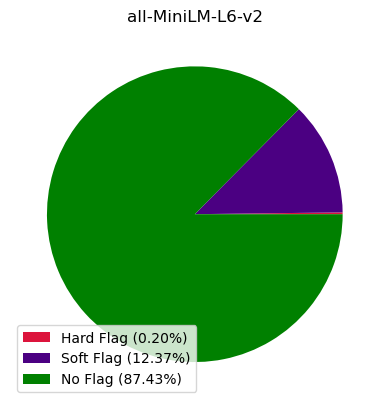

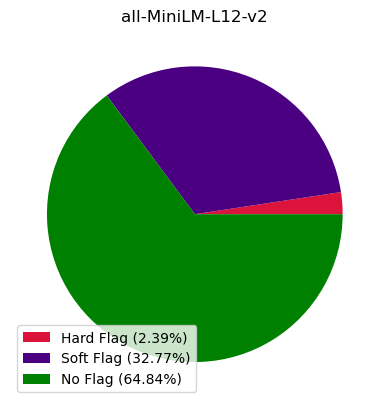

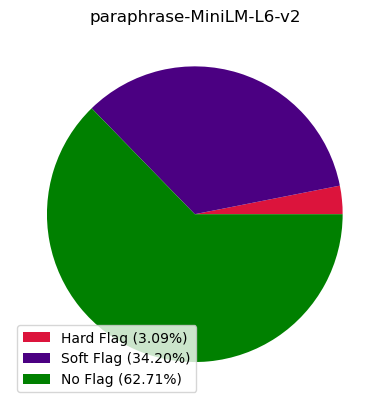

In [9]:
models = results['model_name'].unique().tolist()

for model in models:
    df = results[results['model_name'] == model]

    no_flag = len(df[df['flag'] == 0])
    soft_flag = len(df[df['flag'] == 1])
    hard_flag = len(df[df['flag'] == 2])
    total = hard_flag + soft_flag + no_flag

    flag = [hard_flag, soft_flag, no_flag]
    labels = [f'Hard Flag ({(hard_flag / total) * 100:.2f}%)',
              f'Soft Flag ({(soft_flag / total) * 100:.2f}%)',
              f'No Flag ({(no_flag / total) * 100:.2f}%)']
    colors = ['crimson', 'indigo', 'green']

    plt.pie(flag, colors=colors)
    plt.title(model)
    plt.legend(labels=labels, loc='lower left')
    plt.show()

### OpenAI

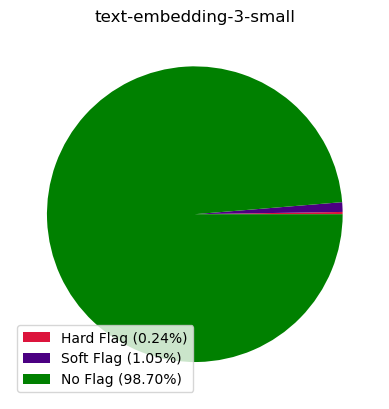

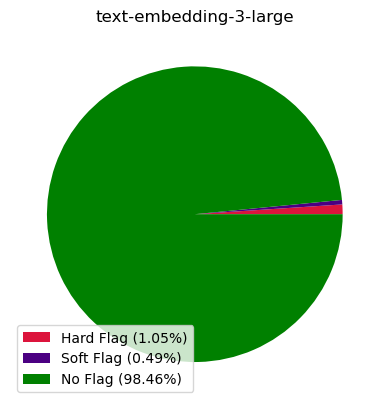

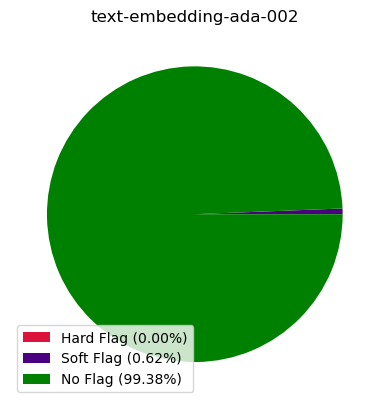

In [11]:
openai_models = openai_results['model_name'].unique().tolist()

for model in openai_models:
    df = openai_results[openai_results['model_name'] == model]

    no_flag = len(df[df['flag'] == 0])
    soft_flag = len(df[df['flag'] == 1])
    hard_flag = len(df[df['flag'] == 2])
    total = hard_flag + soft_flag + no_flag

    flag = [hard_flag, soft_flag, no_flag]
    labels = [f'Hard Flag ({(hard_flag / total) * 100:.2f}%)',
              f'Soft Flag ({(soft_flag / total) * 100:.2f}%)',
              f'No Flag ({(no_flag / total) * 100:.2f}%)']
    colors = ['crimson', 'indigo', 'green']

    plt.pie(flag, colors=colors)
    plt.title(model)
    plt.legend(labels=labels, loc='lower left')
    plt.show()

### OpenAI w/ Altered Thresholds

* $No\;Flag \; = \; \Delta < 1\%$
* $Soft\;Flag \; = \; 1\% \leq \Delta < 5\%$
* $Hard\;Flag \; = \; \Delta \geq 5\%$

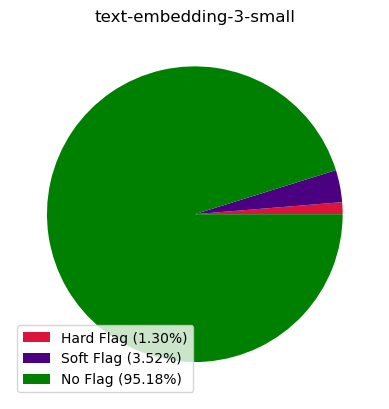

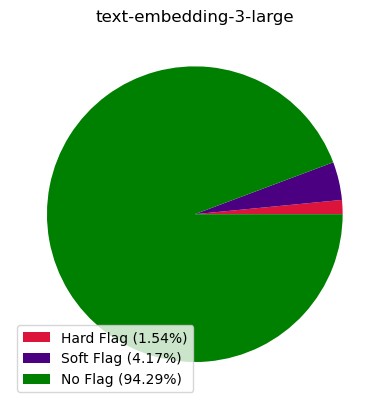

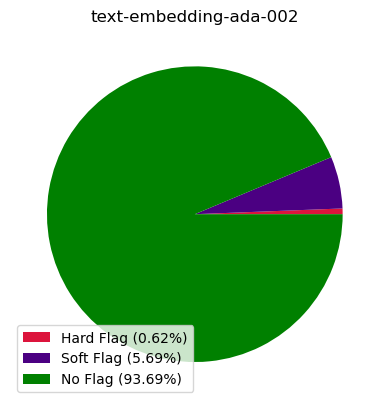

In [13]:
def altered_thresholds(row):
    if row['delta'] < 0.01:
        return 0
    elif row['delta'] >= 0.01 and row['delta'] < 0.05:
        return 1
    elif row['delta'] >= 0.05:
        return 2

openai_results_ = openai_results.copy()
openai_results_['new_flag'] = openai_results.apply(altered_thresholds, axis=1)

for model in openai_models:
    df = openai_results_[openai_results_['model_name'] == model]

    no_flag = len(df[df['new_flag'] == 0])
    soft_flag = len(df[df['new_flag'] == 1])
    hard_flag = len(df[df['new_flag'] == 2])
    total = hard_flag + soft_flag + no_flag

    flag = [hard_flag, soft_flag, no_flag]
    labels = [f'Hard Flag ({(hard_flag / total) * 100:.2f}%)',
              f'Soft Flag ({(soft_flag / total) * 100:.2f}%)',
              f'No Flag ({(no_flag / total) * 100:.2f}%)']
    colors = ['crimson', 'indigo', 'green']

    plt.pie(flag, colors=colors)
    plt.title(model)
    plt.legend(labels=labels, loc='lower left')
    plt.show()

### END